# 本地路径（自定义，按你的情况改）

In [27]:
#你放.ipynb文件和tool_func.py的文件夹路径
currentPath = "D:\PythonEx\machinelearningIntro"

# 你负责的单个的数据集路径
my_data_set_dir = "D:\大学资料\机器学习与数据挖掘\模型与数据\时间序列数据\证券数据\股票\收盘价.csv"

In [28]:
#自动重载外部文件的更新
%load_ext autoreload
%autoreload 2

# 添加项目路径至path
import os
import sys
#currentPath = os.path.join(os.getcwd(),"machinelearningIntro","")
sys.path.append(currentPath)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
#工具类
from tool_func import *

# 小组作业要求

 选择20-30个回归数据集（王双成教授发给你们的数据集），在表中填入不同回归模型的回归误差 ， 回归误差保留4位小数。

回归模型包括：1）计量经济模型：ARAMA、GARCH和VAR；2）循环神经网络：RNN、LSTM和GRU。

对实验结果进行比较与分析


## 导入数据集

In [30]:
import pandas as pd
raw_data = pd.read_csv(my_data_set_dir)
raw_data

,Unnamed: 0,日期,sh600879航天电子,sz002023海特高新,sh600343航天动力,sh600391航发科技,sh600893航发动力,sz000738航发控制,sz300424航新科技,sh600038中直股份,sh600118中国卫星,sh600372中航电子,sz000768中航飞机,sz002111威海广泰,sz000901航天科技,sh600316洪都航空
0,0,2017-11-20,7.85,10.14,13.52,22.34,28.03,16.62,21.77,44.62,26.16,14.16,17.05,15.80,23.67,14.73
1,1,2017-11-17,7.78,10.08,13.75,22.45,27.88,16.47,22.03,44.98,25.80,14.14,17.15,15.97,23.83,14.64
2,2,2017-11-16,8.12,10.78,14.59,23.63,29.60,17.51,23.00,46.02,26.47,14.74,17.93,16.82,25.35,15.22
3,3,2017-11-15,8.22,11.05,14.78,24.13,30.03,17.94,23.48,44.83,26.80,15.03,18.15,16.82,25.47,15.20
4,4,2017-11-14,8.20,11.17,14.90,24.68,30.44,18.27,23.85,45.93,27.34,15.34,18.58,16.98,26.00,15.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4578,4578,1998-12-18,8.75,NaN,NaN,NaN,7.03,6.81,NaN,NaN,8.16,NaN,12.96,NaN,NaN,NaN
4579,4579,1998-12-17,8.88,NaN,NaN,NaN,7.11,6.83,NaN,NaN,8.10,NaN,12.86,NaN,NaN,NaN
4580,4580,1998-12-16,9.20,NaN,NaN,NaN,7.38,6.90,NaN,NaN,8.50,NaN,13.25,NaN,NaN,NaN
4581,4581,1998-12-15,9.35,NaN,NaN,NaN,7.50,6.80,NaN,NaN,8.67,NaN,13.30,NaN,NaN,NaN


## 划分一个时间序列出来，去掉Nan和零值

In [31]:
data = raw_data.iloc[:,3]
data.index = raw_data["日期"]
data.index = pd.DatetimeIndex(data.index).to_period('D')

In [32]:
data = data.dropna()

In [33]:
data = data.drop( index = data[data == 0].index)

In [34]:
data.value_counts()

15.70    14
14.90    11
10.90    11
17.00    11
16.00    10
         ..
23.26     1
23.70     1
15.01     1
9.86      1
13.76     1
Name: sz002023海特高新, Length: 1409, dtype: int64

In [35]:
#这个数据集时间顺序倒了，给它正过来
data = data.iloc[::-1]
data

日期
2004-07-21    15.16
2004-07-22    14.90
2004-07-23    15.14
2004-07-26    15.55
2004-07-27    15.05
              ...  
2017-11-14    11.17
2017-11-15    11.05
2017-11-16    10.78
2017-11-17    10.08
2017-11-20    10.14
Freq: D, Name: sz002023海特高新, Length: 3184, dtype: float64

<AxesSubplot:xlabel='日期'>

D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


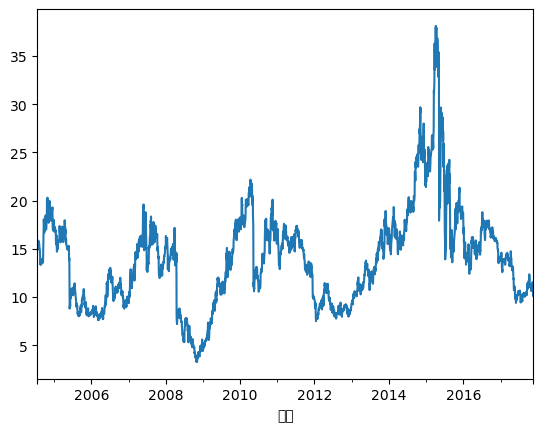

In [36]:
# 画个图看看
data.plot()

## 划分训练集和测试集

In [37]:
#训练集是时间序列的前70%，测试集后30%
mask = int(len(data)*0.7)
train_data = data[0:mask].copy()
test_data = data[mask:-1].copy()

## 导入回归模型

### ARAMA

In [38]:
from statsmodels.tsa.arima.model import ARIMA

#### 求参数

In [39]:
if is_data_stationary(train_data):
    pass
else:
    p,d,q = cal_ARIMA_parameter(data)

p_value =  0.09695163793035344


In [ ]:
from statsmodels.tools.eval_measures import mse
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 定义滚动ARIMA模型
def result_arima_model(data,arima_order):
    data = data.astype('float32')
    total_data = data
    # 使用70%的数据集作为训练集
    # 使用30%的数据集作为测试集
    cut_point = int(len(data)*0.7)
    train,test = total_data[0:cut_point],total_data[cut_point:]
    # 获取每一个训练集的值
    # 定义存储预测结果的prediction表
    history = [x for x in train]
    prediction = []
    for t in range(len(test)):
        model = ARIMA(history,order=arima_order)
        model_fit = model.fit()
        y_pre = model_fit.forecast()[0]
        prediction.append(y_pre)
        # 滚动预测,将最新的测试集合append到history后面作为训练集
        history.append(test[t])
    # 定义评估指标rmse
    rmse = np.sqrt(mean_squared_error(test,prediction))
    mae = mean_absolute_error(test,prediction)
    return rmse

# 定义函数获得最佳pdq
def find_pdq(dataset,p_range,d_range,q_range):
    data_input = dataset
    best_score,best_order = np.inf,None
    for p in p_range:
        for d in d_range:
            for q in q_range:
                rmse = result_arima_model(dataset,(p,d,q))
                try:
                    if rmse < best_score:
                        best_score = mse
                        best_order = (p,d,q)
                    print("mse:%.3f,order:%s" %(rmse,(p,d,q)))
                except:
                    continue
    print("best order is %s, socre is %.3f" %(best_order,rmse))
    return best_score,best_order

# 最后验证得到最佳的p,d,q
find_pdq(data,[1,2,4,6,8,10],[0,1,2],[0,1,2])

mse:0.833,order:(1, 0, 0)


D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
D:\software\anaconda3\envs\MLTensorflowenv\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization faile

#### 初始化模型

In [ ]:

model = ARIMA(train_data)
model_fit = model.fit()
print(model_fit.summary())

In [ ]:
from matplotlib import pyplot as plt

predict = model_fit.predict()
predict

In [ ]:
lt.get_result_df()

### RNN

In [ ]:

import os,math
from tensorflow.keras.layers import Dropout, Dense, SimpleRNN
from sklearn.preprocessing   import MinMaxScaler

# 归一化
sc = MinMaxScaler(feature_range=(0, 1))
training_set = sc.fit_transform(train_data)
test_set = sc.transform(test_data)

### LSTM

In [ ]:
import math
import os

import numpy as np
from keras.layers import LSTM, Dropout, Dense
from sklearn.preprocessing import MinMaxScaler
from tensorflow import optimizers
from tensorflow.keras import Sequential, callbacks
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error


class CgcpLSTM:
    def __init__(self, name):
        """
        构造函数，初始化模型
        :param data_list: 真实数据列表
        """
        # 神经网络名称
        self.name = name
        # 训练集占总样本的比例
        self.train_all_ratio = 0.875
        # 连续样本点数
        self.continuous_sample_point_num = 20
        # 定义归一化：归一化到(0，1)之间
        self.sc = MinMaxScaler(feature_range=(0, 1))
        # 每次喂入神经网络的样本数
        self.batch_size = 64
        # 数据集的迭代次数
        self.epochs = 1000000
        # 每多少次训练集迭代，验证一次测试集
        self.validation_freq = 1
        # 配置模型
        self.model = Sequential([
            # LSTM层（记忆体个数，是否返回输出（True：每个时间步输出ht，False：仅最后时间步输出ht））
            # 配置具有80个记忆体的LSTM层，每个时间步输出ht
            LSTM(80, return_sequences=True),
            Dropout(0.2),
            # 配置具有100个记忆体的LSTM层，仅在最后一步返回ht
            LSTM(100),
            Dropout(0.2),
            Dense(1)
        ])
        # 配置训练方法
        # 该应用只观测loss数值，不观测准确率，所以删去metrics选项，一会在每个epoch迭代显示时只显示loss值
        self.model.compile(
            optimizer=optimizers.Adam(0.001),
            loss='mean_squared_error',  # 损失函数用均方误差
        )
        # 配置断点续训文件
        self.checkpoint_save_path = os.path.abspath(
            os.path.dirname(__file__)) + "\\checkpoint\\" + self.name + "_LSTM_stock.ckpt"
        if os.path.exists(self.checkpoint_save_path + '.index'):
            print('-' * 20 + "加载模型" + "-" * 20)
            self.model.load_weights(self.checkpoint_save_path)

        # 断点续训，存储最佳模型
        self.cp_callback = callbacks.ModelCheckpoint(filepath=self.checkpoint_save_path,
                                                     save_weights_only=True,
                                                     save_best_only=True,
                                                     # monitor='val_accuracy',
                                                     monitor='val_loss',
                                                     )

    def make_set(self, data_list):
        """
        使用历史数据制作训练集和测试集
        :param data_list: 历史数据列表
        :return: train_set, test_set 归一化处理后的训练集合测试集
        """
        # 将历史数据装换为ndarray
        if isinstance(data_list, list):
            data_array = np.array(data_list)
        elif isinstance(data_list, np.ndarray):
            data_array = data_list
        else:
            raise Exception("数据源格式错误")

        # 对一维矩阵进行升维操作
        if len(data_array.shape) == 1:
            data_array = data_array.reshape(data_array.shape[0], 1)

        if data_array.shape[1] != 1:
            raise Exception("数据源形状有误")

        # 按照比例对数据进行分割
        index = int(data_array.shape[0] * self.train_all_ratio)
        train_set = data_array[:index, :]
        test_set = data_array[index:, :]

        print("train_set_shape:{}".format(train_set.shape))
        # 对训练集和测试集进行归一化处理
        train_set, test_set = self.gui_yi(train_set, test_set)

        print("训练集长度：{}".format(len(train_set)))
        print("测试集长度：{}".format(len(test_set)))
        return train_set, test_set

    def gui_yi(self, train_set, test_set):
        """
        对训练集合测试集进行归一化处理
        :param test_set: 未进行归一化的训练集数据
        :param train_set: 未进行归一化处理的测试集数据
        :return: train_set, test_set 归一化处理后的训练集合测试集
        """
        # 求得训练集的最大值，最小值这些训练集固有的属性，并在训练集上进行归一化
        train_set_scaled = self.sc.fit_transform(train_set)
        # 利用训练集的属性对测试集进行归一化
        test_set = self.sc.transform(test_set)
        return train_set_scaled, test_set

    def fan_gui_yi(self, data_set):
        """
        逆归一化
        :param data_set: 需要还原的数据
        :return:
        """
        # 对数据进行逆归一化还原
        data_set = self.sc.inverse_transform(data_set)
        return data_set

    def train(self, x_train, y_train, x_test, y_test):
        """
        训练模型
        :param x_train:
        :param y_train:
        :param x_test:
        :param y_test:
        :return:
        """
        # 训练模型
        history = self.model.fit(x_train, y_train,
                                 # 每次喂入神经网络的样本数
                                 batch_size=self.batch_size,
                                 # 数据集的迭代次数
                                 epochs=self.epochs,
                                 validation_data=(x_test, y_test),
                                 # 每多少次训练集迭代，验证一次测试集
                                 validation_freq=self.validation_freq,
                                 callbacks=[self.cp_callback])
        # 输出模型各层的参数状况
        self.model.summary()
        # 参数提取
        self.save_args_to_file()

        # 获取模型当前loss值
        loss = history.history['loss']
        print("loss:{}".format(loss))
        try:
            val_loss = history.history['val_loss']
            print("val_loss:{}".format(val_loss))
        except:
            pass

    def save_args_to_file(self):
        """
        参数提取，将参数保存至文件
        :return:
        """
        # 指定参数存取目录
        file_path = os.path.abspath(
            os.path.dirname(__file__)) + "\\weights\\"
        # 目录不存在则创建
        if not os.path.exists(file_path):
            os.makedirs(file_path)
        # 打开文本文件
        file = open(file_path + self.name + "_weights.txt", 'w')
        # 将参数写入文件
        for v in self.model.trainable_variables:
            file.write(str(v.name) + '\n')
            file.write(str(v.shape) + '\n')
            file.write(str(v.numpy()) + '\n')
        file.close()

    def test(self, x_test, test_set):
        """
        预测测试
        :param x_test:
        :param test_set: 测试集
        :return:
        """

        # 测试集输入模型进行预测
        predicted_stock_price = self.model.predict(x_test)
        # 对预测数据还原---从（0，1）反归一化到原始范围
        predicted_stock_price = self.fan_gui_yi(predicted_stock_price)

        # 对真实数据还原---从（0，1）反归一化到原始范围
        real_stock_price = self.fan_gui_yi(test_set[self.continuous_sample_point_num:])

        # ##########evaluate##############
        # calculate MSE 均方误差 ---> E[(预测值-真实值)^2] (预测值减真实值求平方后求均值)
        mse = mean_squared_error(predicted_stock_price, real_stock_price)
        # calculate RMSE 均方根误差--->sqrt[MSE]    (对均方误差开方)
        rmse = math.sqrt(mean_squared_error(predicted_stock_price, real_stock_price))
        # calculate MAE 平均绝对误差----->E[|预测值-真实值|](预测值减真实值求绝对值后求均值）
        mae = mean_absolute_error(predicted_stock_price, real_stock_price)
        print('均方误差: %.6f' % mse)
        print('均方根误差: %.6f' % rmse)
        print('平均绝对误差: %.6f' % mae)

    def make_x_y_train_and_test(self, data_list):
        """
        制作x_train（训练集输入特征）, y_train（训练集标签）, x_test（测试集输入特征）, y_test（测试集标签）
        :param data_list:
        :return:
        """
        # 获取归一化后的训练集合测试集
        train_set, test_set = self.make_set(data_list=data_list)
        # 初始化x_train（训练集输入特征）, y_train（训练集标签）, x_test（测试集输入特征）, y_test（测试集标签）
        x_train, y_train, x_test, y_test = [], [], [], []

        # 利用for循环，遍历整个训练集，提取训练集中连续样本为训练集输入特征和标签
        for i in range(self.continuous_sample_point_num, len(train_set)):
            x_train.append(train_set[i - self.continuous_sample_point_num:i, 0])
            y_train.append(train_set[i, 0])
        # 对训练集进行打乱
        np.random.seed(7)
        np.random.shuffle(x_train)
        np.random.seed(7)
        np.random.shuffle(y_train)
        tf.random.set_seed(7)
        # 将训练集由list格式变为array格式
        x_train, y_train = np.array(x_train), np.array(y_train)

        # 使x_train符合RNN输入要求：[送入样本数， 循环核时间展开步数， 每个时间步输入特征个数]。
        x_train = self.change_data_to_rnn_input(x_train)
        # 测试集
        # 利用for循环，遍历整个测试集，提取训练集中连续样本为训练集输入特征和标签
        for i in range(self.continuous_sample_point_num, len(test_set)):
            x_test.append(test_set[i - self.continuous_sample_point_num:i, 0])
            y_test.append(test_set[i, 0])
        # 测试集变array并reshape为符合RNN输入要求：[送入样本数， 循环核时间展开步数， 每个时间步输入特征个数]
        x_test, y_test = np.array(x_test), np.array(y_test)
        print("x_test_shape：{}".format(x_test.shape))
        x_test = self.change_data_to_rnn_input(x_test)
        return train_set, test_set, x_train, y_train, x_test, y_test

    def change_data_to_rnn_input(self, data_array):
        """
        将数据转变为RNN输入要求的维度
        :param data_array:
        :return:
        """
        # 对输入类型进行转换
        if isinstance(data_array, list):
            data_array = np.array(data_array)
        elif isinstance(data_array, np.ndarray):
            pass
        else:
            raise Exception("数据格式错误")
        rnn_input = np.reshape(data_array, (data_array.shape[0], self.continuous_sample_point_num, 1))
        return rnn_input

    def predict(self, history_data):
        """
        使用模型进行预测
        :param history_data: 历史数据list
        :return:预测值
        """
        # 将列表或数组转换为数组并提取最后一组数据
        if isinstance(history_data, list):
            history_data_array = history_data[self.continuous_sample_point_num * -1:]
            history_data_array = np.array(history_data_array)
        elif isinstance(history_data, np.ndarray):
            history_data_array = history_data[self.continuous_sample_point_num * -1:]
        else:
            raise Exception("数据格式错误")

        # 对一维数据进行升维处理
        if len(history_data_array.shape) == 1:
            history_data_array = history_data_array.reshape(1, self.continuous_sample_point_num)

        # 对数据形状进行效验
        if history_data_array.shape[1] != self.continuous_sample_point_num:
            raise Exception("数据形状有误")

        # 对数据进行归一化处理
        history_data_array = history_data_array.T
        history_data_array = self.sc.transform(history_data_array)
        history_data_array = history_data_array.T

        # 转换为RNN需要的数据形状
        history_data_array = self.change_data_to_rnn_input(history_data_array)

        # 测试集输入模型进行预测
        predicted_stock_price = self.model.predict(history_data_array)
        # 对预测数据还原---从（0，1）反归一化到原始范围
        predicted_stock_price = self.fan_gui_yi(predicted_stock_price)
        # 预测值
        value = predicted_stock_price[-1][-1]
        print("预测值：{}".format(value))
        return value


if __name__ == '__main__':
    data_list = [x for x in range(1000)]
    # print(data_list)

    # 初始化模型
    model = CgcpLSTM(name="浓度预测")
    # 获取训练和测试的相关参数
    train_set, test_set, x_train, y_train, x_test, y_test = model.make_x_y_train_and_test(data_list=data_list)
    # 训练模型
    model.train(x_train, y_train, x_test, y_test)
    # 对模型进行测试
    model.test(x_test, test_set)

    # 利用模型进行预测
    history = [x for x in range(50)]
    model.predict(history)

###
